## ***Introduction:***
Some methods are prone to overfitting on the training set. The Bootstrap Aggregation (Bagging) is an ensembling method that works on preventing the overfitting.

To see how bagging can improve model performance, we must start by evaluating how the base classifier performs on the dataset. I will work on decision trees.

# ***Implementation:***

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

I will work on diabetes dataset.
You can see the descriptios in this link below:

https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

In [ ]:
#In order to not losing the feature names while we try to load the data , we set the as_frame = True
DataSet = datasets.load_diabetes(as_frame = True)

In [ ]:
#Load data
X = DataSet.data
y = DataSet.target

In [ ]:
#Split the dataset
xTrain , xTest , yTrain , yTest = train_test_split(X, y, test_size = 0.2, random_state = 25)

In [ ]:
#Base classifier -> decision tree
DT = DecisionTreeClassifier(random_state = 25)
DT.fit(xTrain , yTrain)

DecisionTreeClassifier(random_state=25)

In [ ]:
#Evaluate the Model perfermance (The performance of the base classifier)
Prediction = DT.predict(xTest)
print("The accuracy on training data is: ",accuracy_score(y_true = yTrain , y_pred = DT.predict(xTrain)))
print("But the accuracy on the test data is: ",accuracy_score(y_true = yTest, y_pred = Prediction))

The accuracy on training data is:  1.0
But the accuracy on the test data is:  0.0


***Implementing the bagging classifier:***

In [ ]:
from sklearn.ensemble import BaggingClassifier

In [ ]:
#Create a range of values that represent the number of estimators we want to use in each ensemble
Range = [2,4,6,8,10,12,14,16]
Scores = []
Models = []
for NumberOfEstimators in Range:
    #Create bagging classifier
    BC = BaggingClassifier(n_estimators = NumberOfEstimators , random_state = 25)
    #Fit the model
    BC.fit(xTrain , yTrain)
    Scores.append(accuracy_score(y_true = yTest, y_pred = BC.predict(xTest)))
    Models.append(BC)

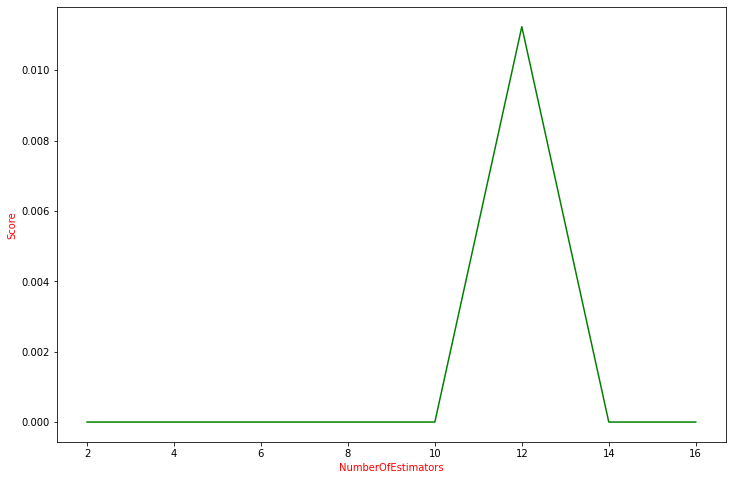

In [ ]:
#Visuallize the improvment in the model performance:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,8))
plt.plot(Range , Scores , color = "g")
plt.ylabel("Score", fontsize = 10 , color = "r")
plt.xlabel("NumberOfEstimators", fontsize = 10 , color = "r")
plt.show()